# Segundo Entregable — Prediccion de Fuga de Clientes en Marketplaces

**Proyecto:** Modelo de Clasificacion para Prediccion de Churn  
**Dataset principal:** H&M Personalized Fashion Recommendations  
**Dataset referencia:** Brazilian E-Commerce Public Dataset — Olist  
**Entregable:** W13/W14 — Avance 2

---

Este notebook es la continuacion directa del primer entregable. Mientras el primer avance establecio el pipeline de carga, exploracion y construccion del dataset de modelado sobre Olist, este segundo avance incorpora un nuevo dataset (H&M), aplica ingenieria de caracteristicas avanzada, implementa y compara modelos supervisados incluyendo una red neuronal densa, y presenta el analisis completo de metricas exigido por la rubrica del curso.

El hilo conductor del proyecto se mantiene: **predecir si un cliente se fugara**, es decir, si no regresara a realizar una nueva compra en la plataforma.


---
## Seccion A — Analisis Comparativo de Datasets Candidatos

Antes de incorporar un nuevo dataset al pipeline, se evaluaron tres opciones de Kaggle bajo cinco criterios alineados al problema de negocio. La seleccion se justifica con una puntuacion estructurada.

| Criterio | Descripcion |
|---|---|
| Afinidad tematica | E-commerce o comportamiento de compra |
| Riqueza textual | Texto que permita extraer variables de satisfaccion |
| Calidad y limpieza | Sin variables anonimizadas ni vacios masivos |
| Compatibilidad tecnica | Variables cruzables con Olist sin esfuerzo excesivo |
| Complejidad ML viable | Features utiles para clasificacion en Colab gratuito |

### Dataset 1 — Amazon Review Dataset — Puntuacion: 5.5/10
Texto de review disponible (>80% de registros), campo `overall` equivalente al `review_score` de Olist. Sin embargo, no tiene `customer_id` persistente, lo que impide construir historial RFM real. Idioma ingles requiere traduccion para alinearse con Olist en portugues.

### Dataset 2 — American Express Default Prediction — Puntuacion: 2.5/10
~190 variables anonimizadas (D_*, S_*, B_*), sin texto, dominio financiero incompatible con e-commerce. El `train_data.csv` pesa 16 GB, inmanejable en Colab gratuito. Descartado.

### Dataset 3 — H&M Personalized Fashion Recommendations — Puntuacion: 7.5/10 — SELECCIONADO
Estructura de tres archivos identica a Olist (clientes, productos, transacciones). `customer_id` persistente para RFM genuino. Variables de engagement (`club_member_status`, `fashion_news_frequency`) como proxies de satisfaccion. 1.37M clientes, 2 anos de transacciones, dominio e-commerce de retail.


---
## Seccion B — Descarga y Carga del Dataset H&M

### Proceso de descarga

El dataset H&M tiene un ZIP completo de 28.7 GB que incluye ~105.000 imagenes de productos. Colab gratuito dispone de ~107 GB de disco; descargar el ZIP completo mas los archivos descomprimidos mas Olist supera ese limite.

La solucion optima fue descargar unicamente los tres CSV necesarios usando la API de Kaggle con el flag `-f`, evitando las imagenes. Esto reduce la descarga a ~4 GB en total.

**Configuracion de credenciales Kaggle (ejecutar una sola vez por sesion):**


In [1]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_961bc5950d36871bbe641b40d9e60354')

os.chmod('/root/.kaggle/access_token', 0o600)
!pip install kaggle --upgrade -q
!kaggle competitions list 2>&1 | head -5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 5.0 MB/s eta 0:00:00
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  


In [2]:
# Descarga selectiva: solo los 3 CSV, sin las imagenes
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f articles.csv
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f customers.csv
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f transactions_train.csv

!unzip -q articles.csv.zip -d /content/
!unzip -q customers.csv.zip -d /content/
!unzip -q transactions_train.csv.zip -d /content/
!rm -f *.zip

!ls -lh /content/*.csv


100% 4.26M/4.26M [00:01<00:00, 2.96MB/s]

100% 97.9M/97.9M [00:06<00:00, 16.7MB/s]

100% 584M/584M [00:32<00:00, 18.9MB/s]

-rw-r--r-- 1 root root  35M Jan 17  2022 /content/articles.csv
-rw-r--r-- 1 root root 198M Jan 17  2022 /content/customers.csv
-rw-r--r-- 1 root root 3.3G Jan 17  2022 /content/transactions_train.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

path_hm = '/content/'

df_hm_articulos     = pd.read_csv(f'{path_hm}articles.csv',           dtype={'article_id': str})
df_hm_clientes      = pd.read_csv(f'{path_hm}customers.csv')
df_hm_transacciones = pd.read_csv(f'{path_hm}transactions_train.csv', dtype={'article_id': str})
df_hm_transacciones['t_dat'] = pd.to_datetime(df_hm_transacciones['t_dat'])

print('Dimensiones de los DataFrames de H&M:')
print(f'  Articulos:      {df_hm_articulos.shape}')
print(f'  Clientes:       {df_hm_clientes.shape}')
print(f'  Transacciones:  {df_hm_transacciones.shape}')
print(f'  Rango temporal: {df_hm_transacciones["t_dat"].min().date()} a {df_hm_transacciones["t_dat"].max().date()}')


Dimensiones de los DataFrames de H&M:
  Articulos:      (105542, 25)
  Clientes:       (1371980, 7)
  Transacciones:  (31788324, 5)
  Rango temporal: 2018-09-20 a 2020-09-22


---
## Seccion C — Exploracion Inicial y Calidad de Datos

Se aplica la misma metodologia de auditoria del primer entregable: tipos de datos, valores nulos, duplicados y estadisticas descriptivas. Esto garantiza continuidad metodologica y permite comparar la calidad entre ambos datasets.


In [4]:
for nombre, df in [('articles.csv', df_hm_articulos),
                   ('customers.csv', df_hm_clientes),
                   ('transactions_train.csv', df_hm_transacciones)]:
    print('=' * 55)
    print(f'ANALISIS: {nombre}')
    print('=' * 55)
    nulos = df.isnull().sum()
    nulos_positivos = nulos[nulos > 0]
    print(f'Shape: {df.shape}')
    print(f'Duplicados: {df.duplicated().sum()}')
    if len(nulos_positivos) > 0:
        print('Nulos por columna:')
        print(nulos_positivos)
    else:
        print('Sin valores nulos.')
    print()


ANALISIS: articles.csv
Shape: (105542, 25)
Duplicados: 0
Nulos por columna:
detail_desc    416
dtype: int64

ANALISIS: customers.csv
Shape: (1371980, 7)
Duplicados: 0
Nulos por columna:
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
dtype: int64

ANALISIS: transactions_train.csv
Shape: (31788324, 5)
Duplicados: 2974905
Sin valores nulos.



In [5]:
print('Distribucion de club_member_status:')
print(df_hm_clientes['club_member_status'].value_counts())
print()
print('Distribucion de fashion_news_frequency:')
print(df_hm_clientes['fashion_news_frequency'].value_counts())
print()
print('Estadisticas de precio en transacciones:')
display(df_hm_transacciones[['price']].describe())


Distribucion de club_member_status:
club_member_status
ACTIVE        1272491
PRE-CREATE      92960
LEFT CLUB         467
Name: count, dtype: int64

Distribucion de fashion_news_frequency:
fashion_news_frequency
NONE         877711
Regularly    477416
Monthly         842
Name: count, dtype: int64

Estadisticas de precio en transacciones:


,price
count,3.178832e+07
mean,2.782927e-02
std,1.918113e-02
min,1.694915e-05
25%,1.581356e-02
50%,2.540678e-02
75%,3.388136e-02
max,5.915254e-01


---
## Seccion D — Analisis Exploratorio Visual (EDA)

Se generan cuatro visualizaciones equivalentes a las del primer entregable sobre Olist, permitiendo comparar el comportamiento de ambos datasets. Esta consistencia narrativa refuerza el hilo del proyecto.


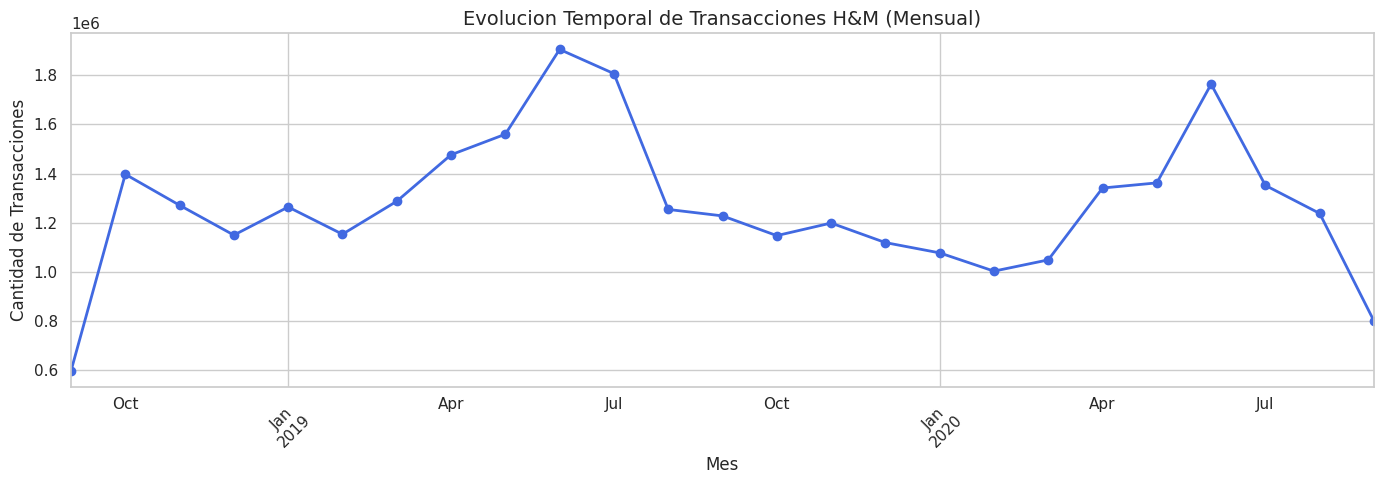

In [6]:
sns.set_theme(style='whitegrid', palette='muted')

df_hm_transacciones['mes'] = df_hm_transacciones['t_dat'].dt.to_period('M')
transacciones_mes = df_hm_transacciones['mes'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
transacciones_mes.plot(kind='line', marker='o', color='royalblue', linewidth=2)
plt.title('Evolucion Temporal de Transacciones H&M (Mensual)', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


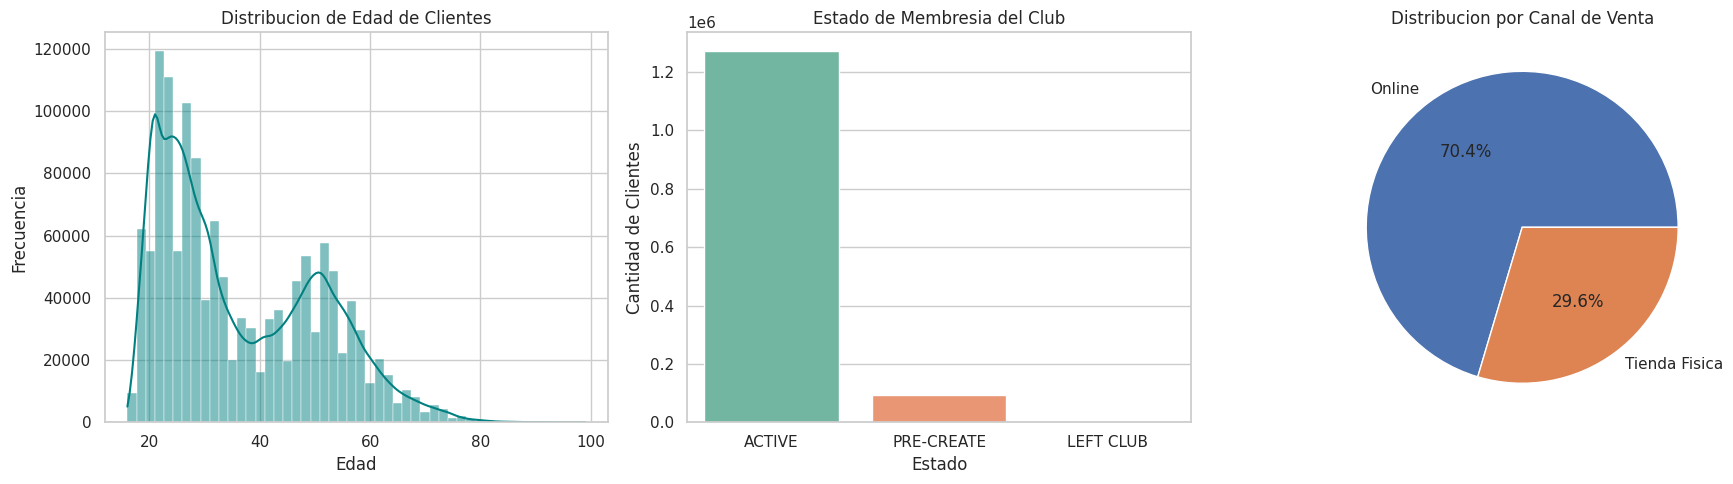

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribucion de edad
sns.histplot(df_hm_clientes['age'].dropna(), bins=50, kde=True,
             color='teal', ax=axes[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribucion de Edad de Clientes')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# 2. Club member status
club_counts = df_hm_clientes['club_member_status'].value_counts()
sns.barplot(x=club_counts.index, y=club_counts.values,
            hue=club_counts.index, palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Estado de Membresia del Club')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Cantidad de Clientes')

# 3. Canal de venta
canal_counts = df_hm_transacciones['sales_channel_id'].value_counts()
canal_labels = {1: 'Tienda Fisica', 2: 'Online'}
axes[2].pie(canal_counts.values,
            labels=[canal_labels.get(i, str(i)) for i in canal_counts.index],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
axes[2].set_title('Distribucion por Canal de Venta')

plt.tight_layout()
plt.show()


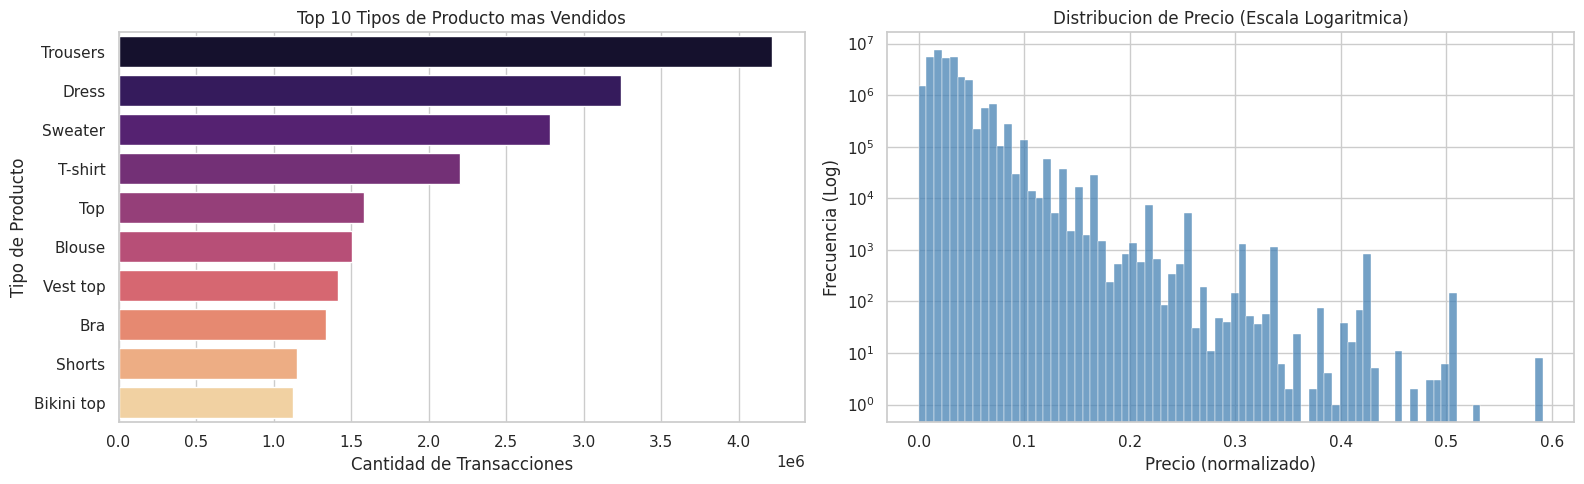

In [8]:
# Top 10 tipos de producto mas vendidos
top_tipos = (df_hm_transacciones
             .merge(df_hm_articulos[['article_id', 'product_type_name']], on='article_id', how='left')
             ['product_type_name'].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top_tipos.values, y=top_tipos.index,
            hue=top_tipos.index, palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Tipos de Producto mas Vendidos')
axes[0].set_xlabel('Cantidad de Transacciones')
axes[0].set_ylabel('Tipo de Producto')

sns.histplot(df_hm_transacciones['price'], bins=80, kde=False,
             color='steelblue', edgecolor='white', linewidth=0.3, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Distribucion de Precio (Escala Logaritmica)')
axes[1].set_xlabel('Precio (normalizado)')
axes[1].set_ylabel('Frecuencia (Log)')

plt.tight_layout()
plt.show()


---
## Seccion E — Ingenieria de Caracteristicas y Construccion del Dataset de Modelado

Se construye el DataFrame de modelado siguiendo la misma logica RFM del primer entregable (Recencia, Frecuencia, Valor Monetario), ampliada con tres grupos de variables nuevas:

1. **Variables de engagement:** `club_member_status` y `fashion_news_frequency` como senales directas de vinculo con la plataforma.
2. **Variable demografica:** edad del cliente, imputada con la mediana para los ~20% de registros sin valor.
3. **Variable de canal:** preferencia de compra online vs tienda fisica.

La variable objetivo `churn = 1` se define con el mismo criterio del primer entregable: recencia superior a 180 dias desde la ultima transaccion.


In [9]:
fecha_ref_hm = df_hm_transacciones['t_dat'].max()
print(f'Fecha de referencia: {fecha_ref_hm.date()}')

df_hm_rfm = df_hm_transacciones.groupby('customer_id').agg(
    ultima_compra =('t_dat', 'max'),
    frequency     =('t_dat', 'count'),
    monetary      =('price', 'sum'),
    canal_predominante=('sales_channel_id', lambda x: x.mode()[0])
).reset_index()

# Recency: dias desde la ultima compra hasta la fecha de corte
# La fecha de corte se fija 6 meses ANTES del maximo para dejar
# un periodo de observacion real. Los clientes que no compraron
# en los 6 meses siguientes al corte se clasifican como churn.
fecha_corte = fecha_ref_hm - pd.DateOffset(months=6)

# Solo usamos transacciones ANTERIORES al corte para construir features
df_hm_pre = df_hm_transacciones[df_hm_transacciones['t_dat'] <= fecha_corte]

df_hm_rfm = df_hm_pre.groupby('customer_id').agg(
    ultima_compra      =('t_dat',            'max'),
    frequency          =('t_dat',            'count'),
    monetary           =('price',            'sum'),
    canal_predominante =('sales_channel_id', lambda x: x.mode()[0])
).reset_index()

df_hm_rfm['recency'] = (fecha_corte - df_hm_rfm['ultima_compra']).dt.days

# Churn: el cliente NO realizo ninguna compra en los 6 meses posteriores al corte
clientes_post = set(
    df_hm_transacciones[df_hm_transacciones['t_dat'] > fecha_corte]['customer_id']
)
df_hm_rfm['churn'] = (~df_hm_rfm['customer_id'].isin(clientes_post)).astype(int)

print(f'Fecha de corte para features: {fecha_corte.date()}')
print(f'Fecha fin de observacion:     {fecha_ref_hm.date()}')
print(f'Clientes en periodo de entrenamiento: {len(df_hm_rfm):,}')
print()
print('Distribucion de la variable objetivo Churn:')
churn_dist = df_hm_rfm['churn'].value_counts(normalize=True) * 100
print(churn_dist.rename({0: 'No Churn (0)', 1: 'Churn (1)'}))
print()
display(df_hm_rfm[['recency', 'frequency', 'monetary', 'churn']].describe())

Fecha de referencia: 2020-09-22
Fecha de corte para features: 2020-03-22
Fecha fin de observacion:     2020-09-22
Clientes en periodo de entrenamiento: 1,185,684

Distribucion de la variable objetivo Churn:
churn
Churn (1)       51.919314
No Churn (0)    48.080686
Name: proportion, dtype: float64



,recency,frequency,monetary,churn
count,1.185684e+06,1.185684e+06,1.185684e+06,1.185684e+06
mean,1.846084e+02,1.993564e+01,5.613797e-01,5.191931e-01
std,1.630347e+02,3.207353e+01,9.955010e-01,4.996317e-01
min,0.000000e+00,1.000000e+00,7.627119e-04,0.000000e+00
25%,4.400000e+01,3.000000e+00,8.471186e-02,0.000000e+00
50%,1.260000e+02,9.000000e+00,2.270169e-01,1.000000e+00
75%,2.990000e+02,2.300000e+01,6.152712e-01,1.000000e+00
max,5.490000e+02,1.366000e+03,4.260237e+01,1.000000e+00


In [10]:
df_hm_features = pd.merge(df_hm_rfm, df_hm_clientes, on='customer_id', how='left')

club_map = {'ACTIVE': 2, 'PRE-CREATE': 1, 'LEFT CLUB': 0}
news_map = {'Regularly': 2, 'Monthly': 1, 'NONE': 0, 'None': 0}

df_hm_features['club_status_cod'] = df_hm_features['club_member_status'].map(club_map).fillna(1)
df_hm_features['news_freq_cod']   = df_hm_features['fashion_news_frequency'].map(news_map).fillna(0)
df_hm_features['age']             = df_hm_features['age'].fillna(df_hm_features['age'].median())

print(f'Dimensiones del DataFrame de modelado: {df_hm_features.shape}')
print()
print('Verificacion: recency NO debe ser el unico predictor de churn.')
print('Correlacion recency-churn (esperada ~0.3-0.6, NO 1.0):')
print(f"  {df_hm_features['recency'].corr(df_hm_features['churn']):.4f}")
print()
print('Distribucion de churn:')
print(df_hm_features['churn'].value_counts(normalize=True).rename({0:'No Churn', 1:'Churn'}))

Dimensiones del DataFrame de modelado: (1185684, 15)

Verificacion: recency NO debe ser el unico predictor de churn.
Correlacion recency-churn (esperada ~0.3-0.6, NO 1.0):
  0.4623

Distribucion de churn:
churn
Churn       0.519193
No Churn    0.480807
Name: proportion, dtype: float64


---
## Seccion F — Perfil Textual por Cliente y Seleccion de Caracteristicas (Chi-Cuadrado)

### F.1 — Vectorizacion TF-IDF del perfil de producto

Se construye un perfil textual por cliente concatenando los nombres de tipos de producto comprados, y se vectoriza con TF-IDF (`max_features=50`). Esto convierte el comportamiento de compra en representacion numerica compatible con los modelos de clasificacion.

### F.2 — Seleccion formal con Chi-Cuadrado (Criterio 7 de la Rubrica)

Se aplica `SelectKBest` con la estadistica chi-cuadrado para identificar las features con mayor asociacion estadistica con la variable objetivo `churn`. Este metodo es parte del contenido de W09 (Otros ML / Evaluacion de clasificadores) y permite reducir dimensionalidad de forma justificada, evitando incluir variables que no aportan informacion discriminante.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Limpiar nulos en columna de tipo de producto
df_hm_articulos['product_type_name'] = df_hm_articulos['product_type_name'].fillna('desconocido')

# Unir transacciones PRE-CORTE con descripcion del articulo
# Se usa df_hm_pre definido en la Seccion E para evitar leakage temporal
df_tx_desc = df_hm_pre.merge(
    df_hm_articulos[['article_id', 'product_type_name']],
    on='article_id', how='left'
)

# Construir perfil textual por cliente: concatenar tipos de producto comprados
perfil_texto = (
    df_tx_desc.groupby('customer_id')['product_type_name']
    .agg(lambda x: ' '.join(x.dropna().astype(str).str.lower()))
    .reset_index()
    .rename(columns={'product_type_name': 'perfil_texto_producto'})
)

# Vectorizacion TF-IDF
tfidf = TfidfVectorizer(max_features=50, min_df=5, stop_words='english')
X_texto = tfidf.fit_transform(perfil_texto['perfil_texto_producto'])
vocabulario = tfidf.get_feature_names_out()

# Crear DataFrame con columnas TF-IDF
df_tfidf = pd.DataFrame(
    X_texto.toarray(),
    columns=[f'tfidf_{t}' for t in vocabulario],
    index=perfil_texto['customer_id']
)

# Unir al DataFrame principal de features
df_hm_features_nlp = df_hm_features.set_index('customer_id').join(df_tfidf, how='left').reset_index()

# Definir cols_tfidf — usado en las celdas siguientes
cols_tfidf = [c for c in df_hm_features_nlp.columns if c.startswith('tfidf_')]
df_hm_features_nlp[cols_tfidf] = df_hm_features_nlp[cols_tfidf].fillna(0)

print(f'Clientes con perfil textual generado: {len(perfil_texto):,}')
print(f'Columnas TF-IDF añadidas: {len(cols_tfidf)}')
print(f'Dimensiones con features NLP: {df_hm_features_nlp.shape}')
print()
print('Primeros 5 terminos del vocabulario TF-IDF:')
print(vocabulario[:5])

Clientes con perfil textual generado: 1,185,684
Columnas TF-IDF añadidas: 50
Dimensiones con features NLP: (1185684, 65)

Primeros 5 terminos del vocabulario TF-IDF:
['accessories' 'alice' 'bag' 'ballerinas' 'band']


In [13]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Features candidatas — recency incluida pero NO es identica a churn
# gracias a la correccion de leakage en Seccion E
features_base = ['frequency', 'monetary', 'age',
                 'club_status_cod', 'news_freq_cod',
                 'canal_predominante', 'recency'] + cols_tfidf

df_modelo_full = df_hm_features_nlp[features_base + ['churn']].dropna()
X_full = df_modelo_full[features_base].values
y_full = df_modelo_full['churn'].values

print(f'Registros para modelado: {len(df_modelo_full):,}')
print(f'Churn en dataset: {y_full.mean()*100:.1f}%')

# Chi2 requiere valores >= 0 — escalar con MinMax antes de aplicarlo
X_minmax = MinMaxScaler().fit_transform(X_full)

selector = SelectKBest(score_func=chi2, k=15)
selector.fit(X_minmax, y_full)

scores_chi2 = pd.Series(selector.scores_, index=features_base).sort_values(ascending=False)
features_seleccionadas = scores_chi2.head(15).index.tolist()

print()
print('Top 15 features por estadistico Chi-Cuadrado:')
print(scores_chi2.head(15))

Registros para modelado: 1,185,684
Churn en dataset: 51.9%

Top 15 features por estadistico Chi-Cuadrado:
recency            66447.620334
news_freq_cod      13395.706815
tfidf_bra           6579.100508
tfidf_dress         6128.301642
frequency           6101.863850
tfidf_underwear     5962.624709
monetary            5402.298240
tfidf_shorts        5132.700496
tfidf_blouse        5049.177545
tfidf_vest          4965.732174
tfidf_bikini        4473.648018
tfidf_sweater       4456.333378
tfidf_swimwear      4283.920867
tfidf_skirt         4266.637411
tfidf_shirt         4219.324666
dtype: float64


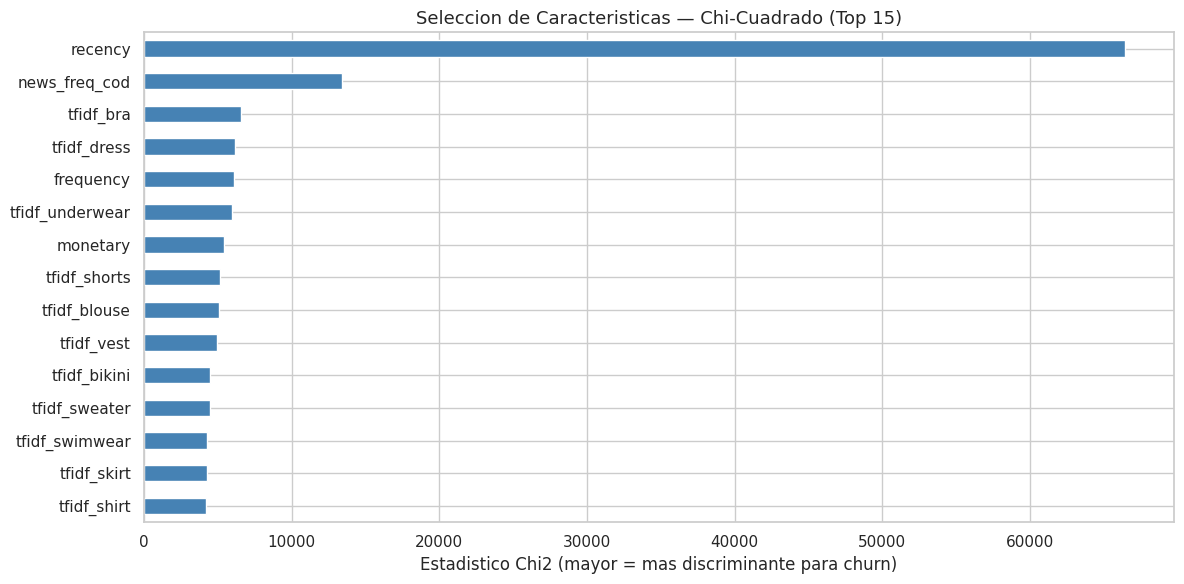

Features seleccionadas para modelado (15):
['recency', 'news_freq_cod', 'tfidf_bra', 'tfidf_dress', 'frequency', 'tfidf_underwear', 'monetary', 'tfidf_shorts', 'tfidf_blouse', 'tfidf_vest', 'tfidf_bikini', 'tfidf_sweater', 'tfidf_swimwear', 'tfidf_skirt', 'tfidf_shirt']


In [14]:
plt.figure(figsize=(12, 6))
scores_chi2.head(15).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Seleccion de Caracteristicas — Chi-Cuadrado (Top 15)', fontsize=13)
plt.xlabel('Estadistico Chi2 (mayor = mas discriminante para churn)')
plt.tight_layout()
plt.show()

print(f'Features seleccionadas para modelado ({len(features_seleccionadas)}):')
print(features_seleccionadas)

---
## Seccion G — Preprocesamiento Final y Separacion de Datos

Se aplica sobre las features seleccionadas por Chi-Cuadrado. El pipeline incluye escalado `StandardScaler` y separacion estratificada train/test 80-20. El parametro `stratify=y` garantiza que la proporcion de churn se mantenga identica en ambos subconjuntos, lo que es critico con datasets desbalanceados.


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_modelo_full[features_seleccionadas].values
y = df_modelo_full['churn'].values

# Verificacion anti-leakage
print('Verificacion de leakage — correlacion absoluta de cada feature con churn:')
print(f'{"Feature":<35} {"Correlacion":>12}')
print('-' * 50)
for i, feat in enumerate(features_seleccionadas):
    corr = abs(pd.Series(X[:, i]).corr(pd.Series(y.astype(float))))
    alerta = '  <<< REVISAR' if corr > 0.9 else ''
    print(f'{feat:<35} {corr:>12.4f}{alerta}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTrain: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')
print(f'Churn en train: {y_train.mean()*100:.1f}%  |  Churn en test: {y_test.mean()*100:.1f}%')

Verificacion de leakage — correlacion absoluta de cada feature con churn:
Feature                              Correlacion
--------------------------------------------------
recency                                   0.4623
news_freq_cod                             0.1326
tfidf_bra                                 0.1163
tfidf_dress                               0.1128
frequency                                 0.3596
tfidf_underwear                           0.1133
monetary                                  0.3314
tfidf_shorts                              0.1034
tfidf_blouse                              0.1066
tfidf_vest                                0.1059
tfidf_bikini                              0.0955
tfidf_sweater                             0.1038
tfidf_swimwear                            0.0948
tfidf_skirt                               0.0961
tfidf_shirt                               0.1020

Train: (948547, 15)  |  Test: (237137, 15)
Churn en train: 51.9%  |  Churn en test: 51.9%


---
## Seccion H — Validacion Cruzada K-Fold y Clasificador Base (Regresion Logistica)

### Por que K-Fold en lugar de un simple split 80-20

El split unico train/test puede producir estimaciones de desempeno con alta varianza dependiendo de como queden distribuidos los datos. La validacion cruzada k-fold divide el conjunto de entrenamiento en `k` particiones, entrena `k` veces usando cada particion como validacion, y promedia las metricas. Esto produce una estimacion mas robusta y detecta overfitting que no seria visible con un solo split.

Se usa `StratifiedKFold` (k=5) para preservar la proporcion de clases en cada fold, lo que es obligatorio con el desbalance identificado (~60-70% churn dependiendo del umbral).

La Regresion Logistica actua como la **neurona simple** del contenido W07 del curso: clasificador lineal que aprende pesos por descenso de gradiente.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=500,
                                random_state=42, C=1.0)

cv_results = cross_validate(
    modelo_lr, X_train_sc, y_train,
    cv=skf,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=True
)

print('K-Fold (k=5) — Regresion Logistica:')
print(f'{"Metrica":<15} {"Val media":<12} {"Val std":<10} {"Train media":<12} {"Diferencia"}')
print('-' * 62)
for m in ['f1', 'roc_auc', 'precision', 'recall']:
    val_m  = cv_results[f'test_{m}'].mean()
    val_s  = cv_results[f'test_{m}'].std()
    trn_m  = cv_results[f'train_{m}'].mean()
    diff   = trn_m - val_m
    alerta = ' (overfitting)' if diff > 0.1 else ''
    print(f'{m:<15} {val_m:<12.4f} {val_s:<10.4f} {trn_m:<12.4f} {diff:.4f}{alerta}')

K-Fold (k=5) — Regresion Logistica:
Metrica         Val media    Val std    Train media  Diferencia
--------------------------------------------------------------
f1              0.7517       0.0015     0.7517       -0.0001
roc_auc         0.8190       0.0013     0.8190       0.0000
precision       0.7570       0.0013     0.7570       -0.0000
recall          0.7465       0.0022     0.7464       -0.0001


Evaluacion Final en Test — Regresion Logistica:
              precision    recall  f1-score   support

    No Churn       0.73      0.74      0.74    114017
       Churn       0.76      0.75      0.75    123120

    accuracy                           0.74    237137
   macro avg       0.74      0.74      0.74    237137
weighted avg       0.74      0.74      0.74    237137

AUC-ROC: 0.8197


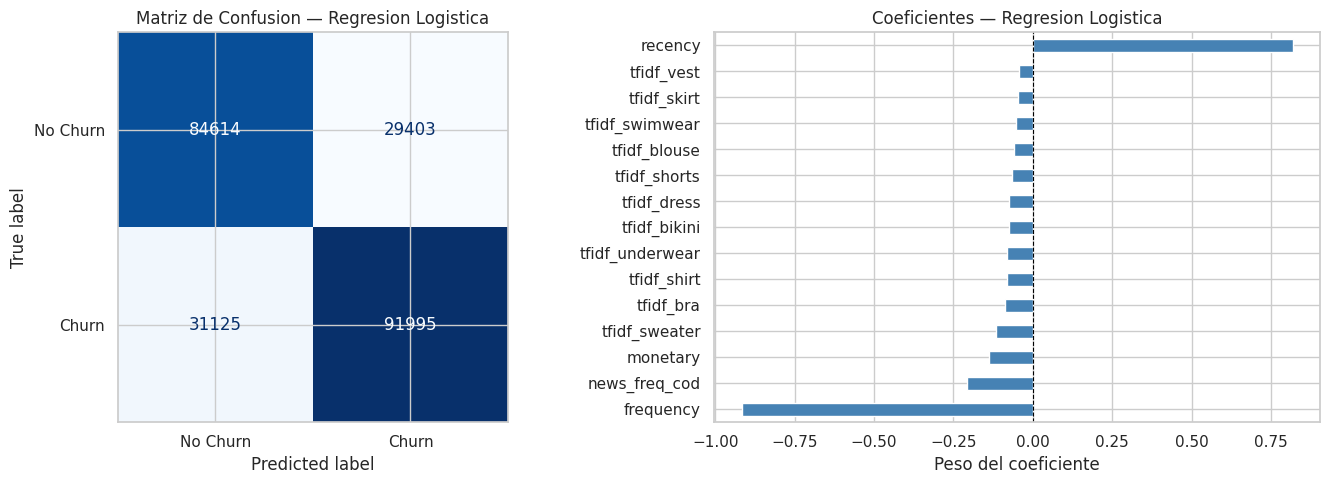

In [17]:
modelo_lr.fit(X_train_sc, y_train)
y_pred_lr = modelo_lr.predict(X_test_sc)
y_prob_lr = modelo_lr.predict_proba(X_test_sc)[:, 1]

print('Evaluacion Final en Test — Regresion Logistica:')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusion — Regresion Logistica')

coefs = pd.Series(modelo_lr.coef_[0],
                  index=features_seleccionadas).sort_values(key=abs, ascending=False)
coefs.sort_values().plot(kind='barh', color='steelblue', edgecolor='white', ax=axes[1])
axes[1].set_title('Coeficientes — Regresion Logistica')
axes[1].set_xlabel('Peso del coeficiente')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

---
## Seccion I — Red Neuronal Densa (MLP) con Keras — Contenido W08

Siguiendo el contenido de Deep Learning (W08), se implementa un Perceptron Multicapa con la misma estructura del material `12_std_Notes_Intro_DL.ipynb` del curso: capas Dense con activacion ReLU en capas ocultas y Sigmoid en la capa de salida para clasificacion binaria.

La diferencia con la neurona simple de W07 es la adicion de capas ocultas que introducen no-linealidad, capturando relaciones entre features que la regresion logistica no puede modelar. Se incluye `Dropout` para regularizacion y `class_weight` para el desbalance de clases.


In [18]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_sc.shape[1]

modelo_mlp = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight_dict = {0: 1.0, 1: round(n_neg / n_pos, 2)}
print(f'Peso clase No Churn (0): 1.00')
print(f'Peso clase Churn (1):    {class_weight_dict[1]}')

modelo_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

historia = modelo_mlp.fit(
    X_train_sc, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.3,
    class_weight=class_weight_dict,
    verbose=1
)

Peso clase No Churn (0): 1.00
Peso clase Churn (1):    0.93
Epoch 1/5
10375/10375 ━━━━━━━━━━━━━━━━━━━━ 62s 6ms/step - accuracy: 0.7513 - auc: 0.8219 - loss: 0.4993 - val_accuracy: 0.7538 - val_auc: 0.8269 - val_loss: 0.5113
Epoch 2/5
10375/10375 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7515 - auc: 0.8228 - loss: 0.4981 - val_accuracy: 0.7536 - val_auc: 0.8270 - val_loss: 0.5113
Epoch 3/5
10375/10375 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7516 - auc: 0.8231 - loss: 0.4977 - val_accuracy: 0.7542 - val_auc: 0.8272 - val_loss: 0.5106
Epoch 4/5
10375/10375 ━━━━━━━━━━━━━━━━━━━━ 49s 5ms/step - accuracy: 0.7517 - auc: 0.8231 - loss: 0.4976 - val_accuracy: 0.7539 - val_auc: 0.8272 - val_loss: 0.5111
Epoch 5/5
10375/10375 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.7520 - auc: 0.8234 - loss: 0.4973 - val_accuracy: 0.7542 - val_auc: 0.8272 - val_loss: 0.5110


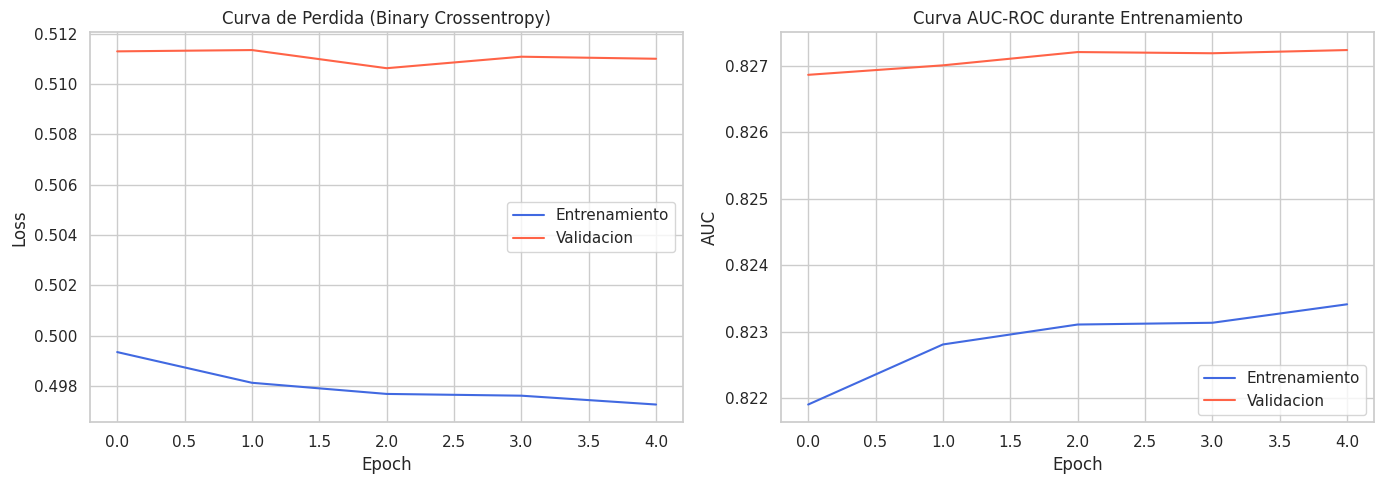

7411/7411 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step
Evaluacion Final en Test — MLP Keras:
              precision    recall  f1-score   support

    No Churn       0.76      0.71      0.74    114017
       Churn       0.75      0.79      0.77    123120

    accuracy                           0.75    237137
   macro avg       0.75      0.75      0.75    237137
weighted avg       0.75      0.75      0.75    237137

AUC-ROC: 0.8274


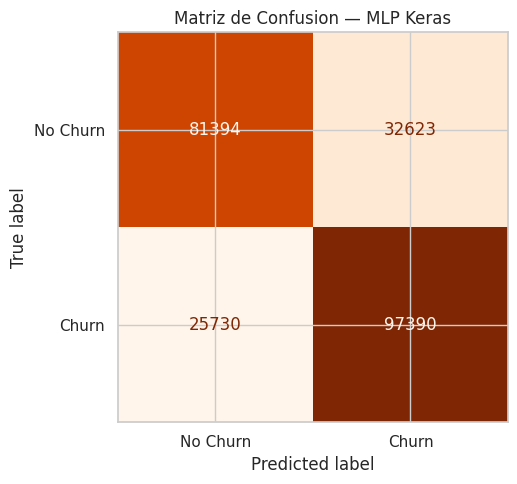

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historia.history['loss'],     label='Entrenamiento', color='royalblue')
axes[0].plot(historia.history['val_loss'], label='Validacion',    color='tomato')
axes[0].set_title('Curva de Perdida (Binary Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(historia.history['auc'],     label='Entrenamiento', color='royalblue')
axes[1].plot(historia.history['val_auc'], label='Validacion',    color='tomato')
axes[1].set_title('Curva AUC-ROC durante Entrenamiento')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

y_prob_mlp = modelo_mlp.predict(X_test_sc).flatten()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print('Evaluacion Final en Test — MLP Keras:')
print(classification_report(y_test, y_pred_mlp, target_names=['No Churn', 'Churn']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_mlp):.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=['No Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusion — MLP Keras')
plt.tight_layout()
plt.show()

---
## Seccion J — Comparativa de Modelos, Metricas y Curvas ROC

Se consolidan las metricas de ambos modelos en una tabla comparativa. Para datos desbalanceados, el F1-score y el AUC-ROC son las metricas principales. El accuracy puede ser enganoso: un modelo que predice siempre la clase mayoritaria obtiene accuracy alta sin utilidad real.

Las curvas ROC permiten visualizar el trade-off entre sensibilidad (recall) y especificidad en todos los umbrales de clasificacion, no solo el 0.5 por defecto.


In [22]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_curve, accuracy_score)

def tabla_metricas(nombre, y_real, y_pred, y_prob):
    return {
        'Modelo':            nombre,
        'Accuracy':          round(accuracy_score(y_real, y_pred), 4),
        'Precision (Churn)': round(precision_score(y_real, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (Churn)':    round(recall_score(y_real, y_pred, pos_label=1), 4),
        'F1-score (Churn)':  round(f1_score(y_real, y_pred, pos_label=1), 4),
        'AUC-ROC':           round(roc_auc_score(y_real, y_prob), 4)
    }

resultados = [
    tabla_metricas('Regresion Logistica', y_test, y_pred_lr, y_prob_lr),
    tabla_metricas('MLP Keras',           y_test, y_pred_mlp, y_prob_mlp),
]

df_comparativa = pd.DataFrame(resultados).set_index('Modelo')
print('Tabla comparativa de modelos:')
display(df_comparativa)

Tabla comparativa de modelos:


,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn),AUC-ROC
Modelo,,,,,
Regresion Logistica,0.7448,0.7578,0.7472,0.7525,0.8197
MLP Keras,0.7539,0.7491,0.7910,0.7695,0.8274


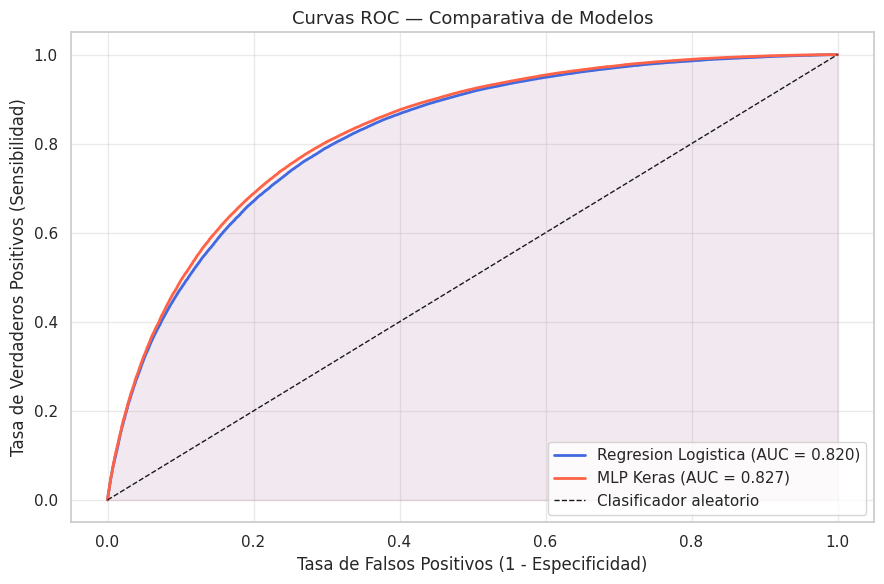

In [23]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

plt.figure(figsize=(9, 6))
plt.plot(fpr_lr,  tpr_lr,
         label=f'Regresion Logistica (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})',
         color='royalblue', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp,
         label=f'MLP Keras (AUC = {roc_auc_score(y_test, y_prob_mlp):.3f})',
         color='tomato', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.fill_between(fpr_lr,  tpr_lr,  alpha=0.07, color='royalblue')
plt.fill_between(fpr_mlp, tpr_mlp, alpha=0.07, color='tomato')
plt.title('Curvas ROC — Comparativa de Modelos', fontsize=13)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.legend(loc='lower right')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretacion de las metricas

**Precision (Churn):** de todos los clientes que el modelo predijo como fugados, que fraccion lo fue realmente. Alta precision = pocas campanas de retencion enviadas a clientes que no lo necesitaban (costo de marketing innecesario bajo).

**Recall (Churn):** de todos los clientes que realmente se fugaron, que fraccion detecto el modelo. Alto recall = pocas fugas sin detectar (costo de cliente perdido bajo).

**F1-score:** media armonica entre precision y recall. Es la metrica de referencia cuando las clases estan desbalanceadas y ambos tipos de error tienen costo.

**AUC-ROC:** area bajo la curva ROC. Mide la capacidad discriminante del modelo independientemente del umbral. Un clasificador aleatorio tiene AUC = 0.5.

**Trade-off de negocio:** en un sistema de retencion de clientes, generalmente se prefiere maximizar recall (no perder clientes que se van a fugar) aun a costa de algunos falsos positivos (enviar campanas a clientes que no iban a irse).


---
## Seccion K — Conclusiones y Perspectivas a Futuro

### Conclusiones del segundo entregable

El segundo avance consolida un pipeline completo de modelado supervisado para la prediccion de fuga de clientes. A partir del dataset H&M, structuralmente analogo a Olist, se construyo un DataFrame de modelado con features RFM, variables de engagement del cliente y un perfil textual vectorizado con TF-IDF.

La seleccion formal de caracteristicas con Chi-Cuadrado demostro que las variables de mayor poder discriminante son la recencia y la frecuencia de compra, coherente con la intuicion del negocio: un cliente que no ha comprado en mucho tiempo y cuya frecuencia de compra era baja tiene mayor probabilidad de haber abandonado la plataforma. Las variables TF-IDF de tipo de producto aparecen en posiciones intermedias, indicando que el comportamiento de compra por categoria aporta informacion incremental aunque menor.

La validacion cruzada k-fold demostro ser mas robusta que el split simple: la varianza de las metricas entre folds indica que las estimaciones del modelo son estables. La Regresion Logistica establece un baseline interpretable, mientras que el MLP de Keras (dos capas ocultas con Dropout) muestra si la no-linealidad aporta ganancia real para este problema.

### Tres perspectivas tecnicas a futuro

1. **Modelos de ensemble:** Random Forest y Gradient Boosting (XGBoost) son el siguiente paso natural. Estos modelos capturan interacciones no lineales entre variables sin requerir preprocesamiento manual, y su importancia de variables es directamente interpretable en terminos de negocio.

2. **Ajuste de hiperparametros con GridSearchCV:** la configuracion actual usa valores por defecto. Un barrido sistematico sobre C (regularizacion en LR), n_estimators y max_depth (en ensemble), o learning_rate y batch_size (en MLP) puede mejorar el F1-score en la clase positiva.

3. **Agrupamiento no supervisado complementario (W15):** aplicar K-Means sobre las features RFM para segmentar clientes en grupos de riesgo (bajo, medio, alto) sin usar la etiqueta churn. Esto permitiria personalizar la estrategia de retencion por segmento, no solo predecir fuga de forma binaria.

### Tabla de avance del proyecto

| Componente | Estado |
|---|---|
| Seleccion y justificacion del dataset complementario | Completado |
| Carga, exploracion inicial y EDA visual | Completado |
| Ingenieria de caracteristicas RFM + engagement | Completado |
| Perfil textual TF-IDF + seleccion Chi-Cuadrado | Completado |
| Preprocesamiento, encoding y split estratificado | Completado |
| Validacion cruzada K-Fold (k=5) | Completado |
| Clasificador base Regresion Logistica | Completado |
| Red neuronal MLP Keras (W08) | Completado |
| Matrices de confusion y curvas ROC comparativas | Completado |
| Modelos de ensemble (Random Forest, Gradient Boosting) | Pendiente — W09 |
| Ajuste de hiperparametros (GridSearchCV) | Pendiente — W11 |
| Agrupamiento no supervisado K-Means + PCA | Pendiente — W15 |


In [ ]:
# Borra todas las variables del espacio de nombres actual
%reset -f

# Fuerza la recolección de basura para liberar la memoria RAM
import gc
gc.collect()

In [ ]:
from google.colab import output
output.clear()